In [1]:
!pip install datasets==2.19.1 scikit-learn==1.5.2 scikeras==0.13.0 underthesea "transformers<5.0"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 542.0/542.0 kB 11.7 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 87.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 89.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 93.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.0/172.0 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 57.1 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2026.2.0
    Uninstalling fsspec-2026.2.0:
      Successfully uninstalled fsspec-2026.2.0
  Attempting uninstall: dill
    Found existing installation: dill 0.4.1
    Uninstalling

In [2]:


import warnings
warnings.filterwarnings('ignore')

# Underthesea - A Vietnamese NLP toolkit
from underthesea import word_tokenize
from underthesea import text_normalize

import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model
# ... (Các dòng import khác của bạn giữ nguyên)

2026-04-07 13:34:35.867427: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775568876.300261      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775568876.421306      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775568877.455324      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568877.455375      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775568877.455378      55 computation_placer.cc:177] computation placer alr

In [3]:
!rm -f patsy.py statsmodels.py seaborn.py

import warnings
warnings.filterwarnings('ignore')
!pip install underthesea
# Underthesea - A Vietnamese NLP toolkit
from underthesea import word_tokenize
from underthesea import text_normalize

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

import wordcloud
import regex as re
import string
import random
import nltk
from datasets import load_dataset
from inspect import signature

# TensorFlow
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Model

from tensorflow.keras.layers import TextVectorization 
from tensorflow.keras.layers import Conv1D, GlobalAveragePooling1D, GlobalMaxPooling1D, concatenate

from scikeras.wrappers import KerasClassifier

# scikit-learn
from sklearn.svm import LinearSVC
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import ShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MaxAbsScaler

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Force the system to load patsy and statsmodels first to avoid circular imports
import patsy
import statsmodels.api as sm

# Load seaborn last
import seaborn as sns
%matplotlib inline

print("Import success!")

Import success!


In [5]:
# Import the function from the datasets library
from datasets import load_dataset

In [6]:
from datasets import load_dataset, disable_progress_bar
import pandas as pd

disable_progress_bar()

dataset = load_dataset("uit-nlp/vietnamese_students_feedback", trust_remote_code=True) 

train_df = dataset['train'].to_pandas()
val_df = dataset['validation'].to_pandas()
test_df = dataset['test'].to_pandas()

df = pd.concat([train_df, val_df, test_df], ignore_index=True)
df = df.sample(frac=1).reset_index(drop=True)
df.rename(columns={'sentence': 'content', 'sentiment': 'label'}, inplace=True)

print("Data loaded and processed successfully!")

Data loaded and processed successfully!


In [7]:
# Save to the Kaggle working directory
df.to_csv('/kaggle/working/vietnamese_students_feedback_processed.csv', index=False, encoding='utf-8-sig')

print("CSV file successfully saved to the /kaggle/working directory!")

CSV file successfully saved to the /kaggle/working directory!


In [8]:
print('Dataset columns, rows:', df.shape)
print('How many labels and their counts?:', df['label'].value_counts())
print('How many kind of topic and their counts?:', df['topic'].value_counts())

Dataset columns, rows: (16175, 3)
How many labels and their counts?: label
2    8038
0    7439
1     698
Name: count, dtype: int64
How many kind of topic and their counts?: topic
0    11607
1     3040
3      816
2      712
Name: count, dtype: int64


### Text Preprocessing

In [9]:
df = df.drop_duplicates("content") # drop duplicates
df = df.dropna() # drop null
print('How many label and their count left?:', df['label'].value_counts())

How many label and their count left?: label
2    8037
0    7439
1     698
Name: count, dtype: int64


In [10]:
!pip install underthesea

In [11]:
from underthesea import text_normalize, word_tokenize

In [12]:
import re, string
emoji_pattern = re.compile("["
                u"\U0001F600-\U0001F64F"
                u"\U0001F300-\U0001F5FF"
                u"\U0001F680-\U0001F6FF"
                u"\U0001F1E0-\U0001F1FF"
                u"\U00002702-\U000027B0"
                u"\U000024C2-\U0001F251"
                u"\U0001f926-\U0001f937"
                u'\U00010000-\U0010ffff'
                u"\u200d"
                u"\u2640-\u2642"
                u"\u2600-\u2B55"
                u"\u23cf"
                u"\u23e9"
                u"\u231a"
                u"\u3030"
                u"\ufe0f"
    "]+", flags=re.UNICODE) # Unicode emojis.

def clean_text(text):
    text = text.lower() # lowercase text

    text = re.sub(emoji_pattern, " ", text) # remove emojis

    text = re.sub(r'([a-z]+?)\1+',r'\1', text) # reduce repeated character (e.g. 'aaabbb' -> 'ab')

    # Ensure space before and after any punctuation mark
    text = re.sub(r"(\w)\s*([" + string.punctuation + "])\s*(\w)", r"\1 \2 \3", text)
    text = re.sub(r"(\w)\s*([" + string.punctuation + "])", r"\1 \2", text)

    text = re.sub(f"([{string.punctuation}])([{string.punctuation}])+",r"\1", text) # reduce consecutive punctuation

    # Remove any leading or trailing spaces, or leading or trailing punctuation marks from the text
    text = text.strip()
    while text.endswith(tuple(string.punctuation+string.whitespace)):
        text = text[:-1]
    while text.startswith(tuple(string.punctuation+string.whitespace)):
        text = text[1:]

    text = text.translate(str.maketrans('', '', string.punctuation)) # remove all punctuation

    text = re.sub(r"\s+", " ", text) # reduce multiple spaces

    text = text_normalize(text) # make sure punctuation is in the right letter (Vietnamese case)
    text = word_tokenize(text, format="text") # tokenize the cleaned text
    # text = unidecode(text) # remove accent marks from sentences (no significant difference when accent marks is removed or kept)

    '''
    Proper tokenization allows models or algorithms to understand the semantics of the text better.
    For instance, `"đi chơi" (go play)` should be treated as one unit
    instead of two separate words "đi" (go) and "chơi" (play) for proper semantic understanding.
    '''
    return text

In [13]:
df['corpus'] = df['content'].map(lambda text: clean_text(text))
# Final check
df.head(30)

,content,label,topic,corpus
0,thân mến .,1,3,thân_mến
1,thầy nói tiếng khá khó nghe và không sử dụng m...,0,0,thầy nói tiếng khá khó nghe và không sử_dụng m...
2,phương pháp giảng dạy của giảng viên chưa tạo ...,0,0,phương_pháp giảng_dạy của giảng_viên chưa tạo ...
3,giảng dạy không rõ ràng còn hàn lâm .,0,0,giảng_dạy không rõ_ràng còn hàn_lâm
4,sinh viên tìm tòi cách khác để có được kết quả...,0,1,sinh_viên tìm_tòi cách khác để có được kết_quả...
5,"vui tính , hòa đồng với sinh viên .",2,0,vui tính hòa đồng với sinh_viên
6,"slide quá khó hiểu , nhiều chỗ không giải thíc...",0,1,slide quá khó hiểu nhiều chỗ không giải_thích ...
7,diễn đạt trong giảng dạy không được tốt lắm .,0,0,diễn_đạt trong giảng_dạy không được tốt lắm
8,quá nhiều .,0,3,quá nhiều
9,đó là việc giáo viên vừa giảng bài vừa code ch...,2,0,đó là việc giáo_viên vừa giảng bài vừa code ch...


### Exploratory Data Analysis

Number of words: 16001
Most common words: [('thầy dạy hay dễ hiểu', 4), ('giảng_viên tận_tâm nhiệt_tình', 3), ('thầy dạy nhiệt_tình tận_tâm', 3), ('nhiệt_tình vui_tính', 3), ('giảng_viên nhiệt_tình tận_tâm', 3), ('nhiệt_tình tâm_huyết', 3), ('giảng_viên dạy nhiệt_tình dễ hiểu', 3), ('em cảm_ơn', 3), ('vui tính hòa đồng với sinh_viên', 2), ('giáo_viên nhiệt_tình vui_vẻ', 2), ('cô dạy chậm dễ hiểu', 2), ('thầy rất vui_tính dạy dễ hiểu', 2), ('thầy dễ_thương nhiệt_tình', 2), ('dạy hay nhiệt_tình', 2), ('giáo_viên nhiệt_tình tận_tâm', 2)]


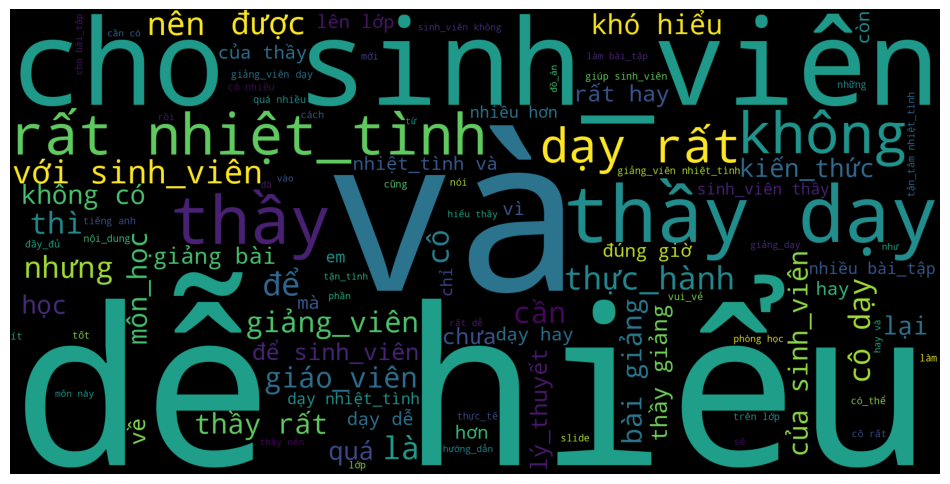

In [14]:
# Create bag-of-words
all_words = [token for token in df['corpus'].tolist() if token and token != '']

corpus=' '.join(all_words)
all_words = nltk.FreqDist(all_words)

# Print the total number of words and the 15 most common words
print('Number of words: {}'.format(len(all_words)))
print('Most common words: {}'.format(all_words.most_common(15)))

plt.figure(figsize=(12,8))
word_cloud = wordcloud.WordCloud(max_words=100,background_color ="black",
                               width=2000,height=1000,mode="RGB").generate(corpus)
plt.axis("off")
plt.imshow(word_cloud)

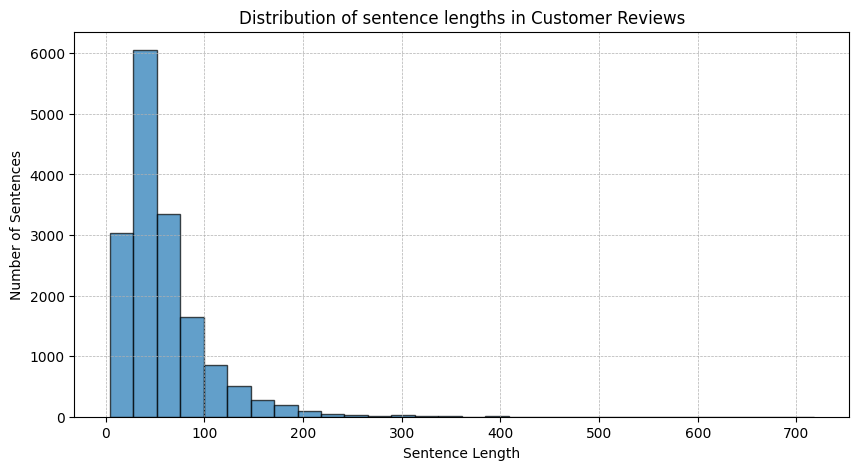

In [15]:
# Calculate the length of each sentence directly
lengths = df['content'].apply(len)

# Plot histogram
plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=30, edgecolor='k', alpha=0.7)
plt.title('Distribution of sentence lengths in Customer Reviews')
plt.xlabel('Sentence Length')
plt.ylabel('Number of Sentences')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

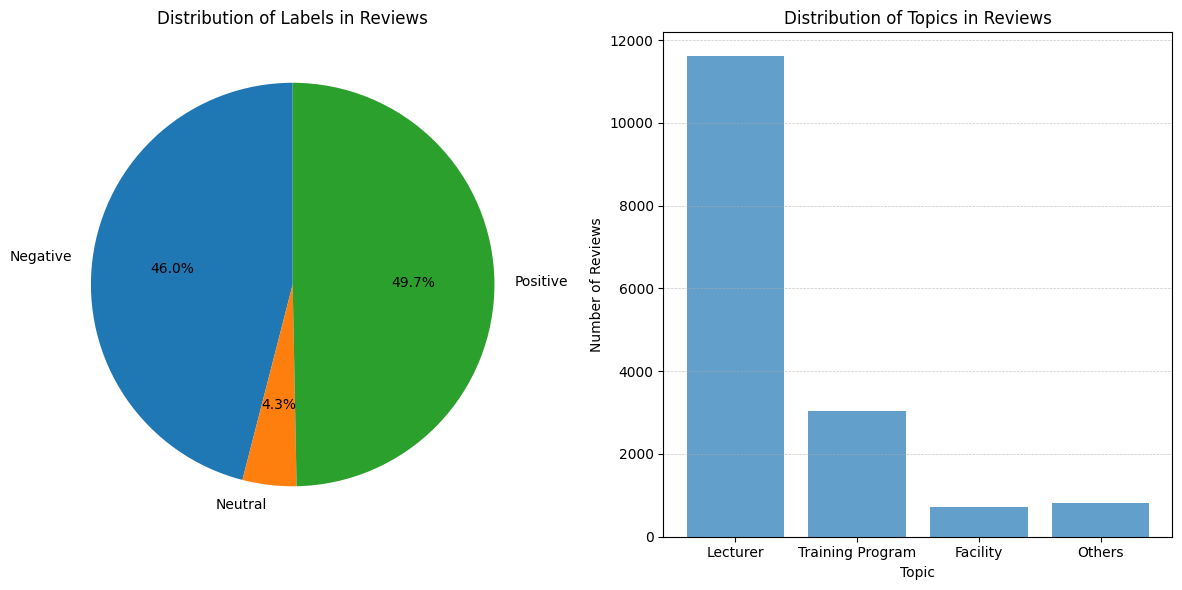

In [16]:
# Count the occurrences of each label and topic
label_counts = df['label'].value_counts().sort_index()
topic_counts = df['topic'].value_counts().sort_index()

# Set up the figure and axis
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for labels
labels = ['Negative', 'Neutral', 'Positive']  # updated labels
ax[0].pie(label_counts, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Distribution of Labels in Reviews')

# Bar chart for topics
topics = ['Lecturer', 'Training Program', 'Facility', 'Others']  # updated topics
ax[1].bar(topics, topic_counts, alpha=0.7)
ax[1].set_title('Distribution of Topics in Reviews')
ax[1].set_xlabel('Topic')
ax[1].set_ylabel('Number of Reviews')
ax[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

# Show the plots
plt.tight_layout()
plt.show()

In [17]:
# First, split the data into 80% training and 20% temporary testing.
train_sentences, test_sentences, train_labels, test_labels = train_test_split(
    df['corpus'],
    df['label'],
    test_size=0.1,
    stratify=df['topic'],
    random_state=42
)

### Over-sampling

In [18]:
from sklearn.utils import resample

# Separate neutral comments
neutral_indices = np.where(train_labels == 1)[0]
oversample_size = len(train_labels[train_labels == 0]) - len(neutral_indices)

# Over-sample the neutral comments
oversampled_neutral_indices = resample(neutral_indices,
                                       replace=True,
                                       n_samples=oversample_size)

# Combine the original sentences and labels with the oversampled data
oversampled_neutral_sentences = np.array(train_sentences)[oversampled_neutral_indices]

train_sentences_oversampled = np.concatenate([train_sentences, oversampled_neutral_sentences], axis=0)
train_labels_oversampled = np.concatenate([train_labels, np.array([1] * oversample_size)], axis=0)

In [19]:
oversampled_neutral_sentences = np.array(train_sentences)[oversampled_neutral_indices]

train_sentences_oversampled = np.concatenate([train_sentences, oversampled_neutral_sentences], axis=0)
train_labels_oversampled = pd.Series(train_labels_oversampled)

In [20]:
# Count occurrences of each label in train_labels_oversampled
unique_labels, counts = np.unique(train_labels_oversampled, return_counts=True)

# Display the distribution
for label, count in zip(unique_labels, counts):
    print(f"Label {label}: {count}")

Label 0: 6720
Label 1: 6720
Label 2: 7229


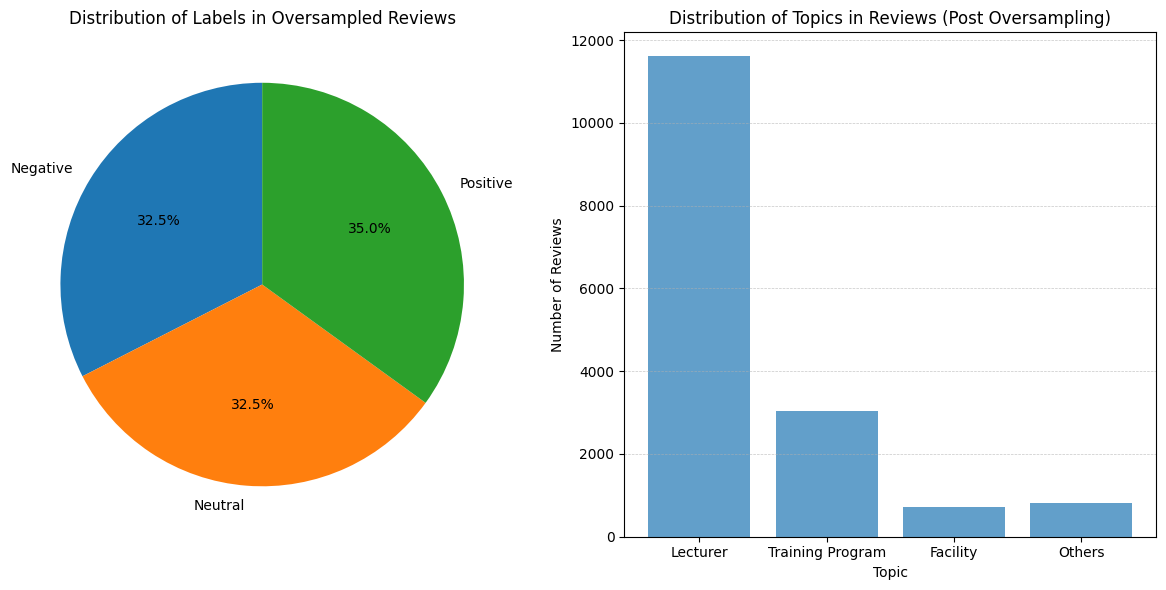

In [21]:
# First, you need to create a new DataFrame or series for your oversampled data
# For this example, let's assume your oversampled DataFrame is `df_oversampled`

# Update the label counts based on the oversampled data
label_counts_oversampled = pd.Series(train_labels_oversampled).value_counts().sort_index()

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Pie chart for labels after over-sampling
labels = ['Negative', 'Neutral', 'Positive']
ax[0].pie(label_counts_oversampled, labels=labels, autopct='%1.1f%%', startangle=90)
ax[0].set_title('Distribution of Labels in Oversampled Reviews')

# Bar chart for topics (assuming they were oversampled too)
topics = ['Lecturer', 'Training Program', 'Facility', 'Others']
ax[1].bar(topics, topic_counts, alpha=0.7)
ax[1].set_title('Distribution of Topics in Reviews (Post Oversampling)')
ax[1].set_xlabel('Topic')
ax[1].set_ylabel('Number of Reviews')
ax[1].grid(True, axis='y', linestyle='--', linewidth=0.5, alpha=0.7)

plt.tight_layout()
plt.show()

### Bag of Words

In [22]:
# Initialize the CountVectorizer
vectorizer = CountVectorizer()

# Fit the vectorizer on the training data only
vectorizer.fit(train_sentences)

CountVectorizer()

In [23]:
sample_sentences = df['corpus'].head(5).tolist() # select a sample of sentences
sample_transformed = vectorizer.transform(sample_sentences) # transform the sample sentences

sample_array = sample_transformed.toarray() # convert the transformed data

# Print results for each sentence in the sample
for idx, sentence in enumerate(sample_sentences):
    print(f"Sentence: {sentence}")
    print("Token : Count")
    for token, count in zip(vectorizer.get_feature_names_out(), sample_array[idx]):
        if count > 0:
            print(f"{token} : {count}")
    print("------\n")

Sentence: thân_mến
Token : Count
thân_mến : 1
------

Sentence: thầy nói tiếng khá khó nghe và không sử_dụng micro nên em không_thể hiểu toàn_bộ những điều thầy nói
Token : Count
em : 1
hiểu : 1
khá : 1
khó : 1
không : 1
không_thể : 1
micro : 1
nghe : 1
những : 1
nên : 1
nói : 2
sử_dụng : 1
thầy : 2
tiếng : 1
toàn_bộ : 1
và : 1
điều : 1
------

Sentence: phương_pháp giảng_dạy của giảng_viên chưa tạo được sự chủ_động cho sinh_viên
Token : Count
cho : 1
chưa : 1
chủ_động : 1
của : 1
giảng_dạy : 1
giảng_viên : 1
phương_pháp : 1
sinh_viên : 1
sự : 1
tạo : 1
được : 1
------

Sentence: giảng_dạy không rõ_ràng còn hàn_lâm
Token : Count
còn : 1
giảng_dạy : 1
hàn_lâm : 1
không : 1
rõ_ràng : 1
------

Sentence: sinh_viên tìm_tòi cách khác để có được kết_quả giống nhưng không chấp_nhận
Token : Count
chấp_nhận : 1
cách : 1
có : 1
giống : 1
khác : 1
không : 1
kết_quả : 1
nhưng : 1
sinh_viên : 1
tìm_tòi : 1
được : 1
để : 1
------



In [24]:
# Convert the entire oversampled sentences into the Bag-of-Words representation
X_oversampled_bow = vectorizer.transform(train_sentences_oversampled)
y_oversampled_bow = train_labels_oversampled

### Text Vectorization


In [25]:
MAX_VOCAB_LENGTH = 20000

sequence_lengths = [len(sentence.split()) for sentence in train_sentences] # Calculate the length of each sentence in the training data
MAX_LENGTH = int(np.percentile(sequence_lengths, 95)) # Set MAX_LENGTH as the 95th percentile of the sequence lengths

In [26]:
text_vectorizer = TextVectorization(max_tokens=MAX_VOCAB_LENGTH, # Maximum size of the vocabulary for this layer
                                    standardize="lower_and_strip_punctuation", # Text will be lowercased and all punctuation removed
                                    split="whitespace", # Split on whitespace
                                    ngrams=None,
                                    output_mode="int", # Outputs integer indices, one integer index per split string token
                                    output_sequence_length=MAX_LENGTH) # the output will have its time dimension padded or truncated to exactly output_sequence_length values

text_vectorizer.adapt(train_sentences) # Computes a vocabulary of string terms from tokens in a dataset.

I0000 00:00:1775568961.898617      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775568961.904543      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [27]:
words_in_vocab = text_vectorizer.get_vocabulary()
top_5_words = words_in_vocab[:5] # ([UNK] token is unknown words)
bottom_5_words = words_in_vocab[-5:]
print(f"Number of words in vocab: {len(words_in_vocab)}")
print(f"Top 5 most common words: {top_5_words}")
print(f"Bottom 5 least common words: {bottom_5_words}")

Number of words in vocab: 4531
Top 5 most common words: ['', '[UNK]', np.str_('thầy'), np.str_('sinhviên'), np.str_('dạy')]
Bottom 5 least common words: [np.str_('2000'), np.str_('1983'), np.str_('19'), np.str_('140'), np.str_('14')]


### Embedding

In [28]:
def create_embedding_layer(input_dim=MAX_VOCAB_LENGTH, output_dim=128, embeddings_initializer="uniform", input_length=MAX_LENGTH, name=None):
    """
    Create an Embedding layer for use in a deep learning model.

    Parameters:
    - input_dim (int): Size of the input vocabulary.
    - output_dim (int, optional): Dimension of the dense embedding. Defaults to 128.
    - embeddings_initializer (str or keras.initializers, optional): Initializer for the embeddings matrix. Defaults to "uniform".
    - input_length (int, optional): Length of input sequences, when it is constant.
    - name (str, optional): Name of the layer. Defaults to None.

    Returns:
    - TensorFlow/Keras Embedding layer.
    """
    return layers.Embedding(
        input_dim=input_dim,
        output_dim=output_dim,
        embeddings_initializer=embeddings_initializer,
        input_length=input_length,
        name=name
    )

### Machine Learning Models

#### Optimized Functions for ML Training

In [29]:
def create_ml_model(model_type, **kwargs):
    '''
    Create Machine Learning model
    '''
    models = {
        'naive_bayes': MultinomialNB,
        'svm': LinearSVC,
        'random_forest': RandomForestClassifier,
        'logistic_regression': LogisticRegression,
        'ml_ensemble': lambda: create_ml_stacking_classifier(**kwargs)
    }

    # Retrieve the model class based on the model_type argument
    model = models.get(model_type.lower())

    # Check if the model type exists
    if model:
        return model(**kwargs)
    else:
        supported_models = ", ".join(models.keys())
        print(f"Error: Model type '{model_type}' is not supported.\n"
              f"Supported models are: {supported_models}.\n"
              f"Please add your perferred model to create_model function.")
        return None

In [30]:
def kfold_evaluation(model, X, y, kfold):
    '''
    1. Train ML model on KFold

    2. Return metrics for each KFold and all KFolds
    '''
    fold_results = [] # average validation data results on all Kfolds
    fold_result_each_kfold = [] # training and validation results on each Kfold

    for train_index, val_index in skf.split(X, y):
        X_train, X_val = X[train_index], X[val_index]
        y_train, y_val = y[train_index], y[val_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict on both sets
        train_predictions = model.predict(X_train)
        val_predictions = model.predict(X_val)

        # Calculate metrics for both sets
        train_metrics = calculate_results(y_train, train_predictions)
        val_metrics = calculate_results(y_val, val_predictions)

        fold_result = {
            'fold': len(fold_results) + 1,
            'train_metrics': train_metrics,
            'validation_metrics': val_metrics
        }

        fold_results.append(val_metrics)
        fold_result_each_kfold.append(fold_result)

    # Compute the average metrics over all folds
    model_results = {
        "accuracy": np.mean([result["accuracy"] for result in fold_results]),
        "precision": np.mean([result["precision"] for result in fold_results]),
        "recall": np.mean([result["recall"] for result in fold_results]),
        "f1": np.mean([result["f1"] for result in fold_results])
    }

    # Retrain the model on the entire dataset
    model.fit(X, y)

    return model, fold_result_each_kfold, model_results

In [31]:
def calculate_results(y_true, y_pred):
    '''
    Calculate accuracy, precision, recall, f1 score for a model
    '''
    model_accuracy = accuracy_score(y_true, y_pred) * 100  # Scale to 1-100
    model_precision, model_recall, model_f1, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted")

    model_results = {
        "accuracy": model_accuracy,
        "precision": model_precision,
        "recall": model_recall,
        "f1": model_f1
    }

    return model_results

In [32]:
def compare_baseline_to_new_results(baseline_results, new_model_results, baseline_name='Baseline', new_model_name='New Model'):
    '''
    Compare baseline and new model results on metrics and plot the results using a line graph.
    '''
    metrics = list(baseline_results.keys())
    baseline_scores = [baseline_results[metric] * 100 if metric != 'accuracy' else baseline_results[metric] for metric in metrics]
    new_model_scores = [new_model_results[metric] * 100 if metric != 'accuracy' else new_model_results[metric] for metric in metrics]

    # Textual comparison
    # for key, value in baseline_results.items():
        # print(f"{baseline_name} {key}: {value:.2f}, {new_model_name} {key}: {new_model_results[key]:.2f}, Difference: {new_model_results[key]-value:.2f}")

    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for baseline, Red for new model

    # Plotting
    x = np.arange(len(metrics))
    fig, ax = plt.subplots(figsize=(10, 4))
    ax.plot(x, baseline_scores, label=baseline_name, marker='o', markersize=6, linewidth=2, color=colors[0])
    ax.plot(x, new_model_scores, label=new_model_name, marker='s', markersize=6, linewidth=2, color=colors[1])

    # Adjust y-axis range
    max_score = max(max(baseline_scores), max(new_model_scores))
    min_score = min(min(baseline_scores), min(new_model_scores))
    ax.set_ylim([min_score - 1, max_score + 1])  # Add padding to the top and bottom
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Add some text for labels, title and custom x-axis tick labels, etc.
    ax.set_ylabel('Scores (%)')
    ax.set_title(f'Performance Comparison: {baseline_name} vs {new_model_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    # Attach a text label at each marker, displaying its height with increased vertical offset
    label_offset = 0.25  # Increased vertical offset for the labels
    for i in range(len(metrics)):
        ax.text(x[i], baseline_scores[i] + label_offset, f'{baseline_scores[i]:.2f}%', ha='center', va='bottom')
        ax.text(x[i], new_model_scores[i] + label_offset, f'{new_model_scores[i]:.2f}%', ha='center', va='bottom')

    fig.tight_layout()
    plt.show()

In [33]:
def format_metrics_compact(metrics):
    '''
    Helper function to format metrics compactly
    '''
    return ", ".join([f"{key.capitalize()}: {value:.2f}" for key, value in metrics.items()])

def display_all_folds_results(model_name, model_results):
    '''
    Print average metrics of validation data on all KFolds
    '''
    print(f"Average {model_name} Performance Metrics Across All Folds (on validation data):")
    print(f"- Accuracy: {model_results['accuracy']:.2f}%")
    print(f"- Precision: {model_results['precision']:.4f}")
    print(f"- Recall: {model_results['recall']:.4f}")
    print(f"- F1 Score: {model_results['f1']:.4f}")

In [34]:
def display_each_fold_result(model_name, fold_results):
    '''
    Print metrics of training and validation data on each KFold and plot the accuracy graph using Seaborn.
    '''
    # Set up the seaborn style and palette
    sns.set(style="whitegrid", palette="muted")
    colors = ["#3498db", "#e74c3c"]  # Blue for Training, Red for Validation

    # Header
    print(f"{model_name} Performance Metrics Across Each Fold (on training and validation data):")
    print()
    print(f"{'Fold':<5} | {'Training Metrics':<70} | {'Validation Metrics':<70}")
    print("-" * 150)

    # Prepare data for plotting
    train_accuracies = []
    val_accuracies = []
    folds = []

    # Display results for each fold and collect data for graph
    for result in fold_results:
        train_metrics_formatted = format_metrics_compact(result['train_metrics'])
        val_metrics_formatted = format_metrics_compact(result['validation_metrics'])
        print(f"{result['fold']:<5} | {train_metrics_formatted:<70} | {val_metrics_formatted:<70}")

        # Append data for graph
        folds.append(result['fold'])
        train_accuracies.append(result['train_metrics']['accuracy'])
        val_accuracies.append(result['validation_metrics']['accuracy'])

    # Plotting the accuracies using Seaborn
    fig, ax = plt.subplots(figsize=(10, 4))
    sns.lineplot(x=folds, y=train_accuracies, label='Training Accuracy', marker='o', color=colors[0])
    sns.lineplot(x=folds, y=val_accuracies, label='Validation Accuracy', marker='o', color=colors[1])
    ax.set_facecolor('#f8f9fa')  # Light gray background

    # Adding percentages on markers
    label_offset = 0.25  # Increased vertical offset for the labels
    for i, (tr_acc, val_acc) in enumerate(zip(train_accuracies, val_accuracies)):
        ax.text(folds[i], tr_acc + label_offset, f"{tr_acc:.2f}%", ha='center', va='bottom')
        ax.text(folds[i], val_acc + label_offset, f"{val_acc:.2f}%", ha='center', va='bottom')

    plt.title(f"{model_name} model: Training vs Validation Accuracy per Fold")
    plt.xlabel('Fold')
    plt.ylabel('Accuracy (%)')
    plt.xticks(folds)
    plt.legend()
    ax.margins(y=0.2)  # Add 10% padding to the top and bottom
    fig.tight_layout()
    plt.show()

In [35]:
from sklearn.model_selection import StratifiedKFold

# Initialize Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True)

#### Model 0: Logistic Regression (Base Model)

In [36]:
lr_model = create_ml_model('logistic_regression', max_iter=5000, solver='saga', multi_class='multinomial') # Set for multi-class classification

In [37]:
lr_model, lr_each_fold_results, lr_results = kfold_evaluation(lr_model, X_oversampled_bow, y_oversampled_bow, skf)

In [38]:
display_all_folds_results("Logistic Regression", lr_results)

Average Logistic Regression Performance Metrics Across All Folds (on validation data):
- Accuracy: 90.13%
- Precision: 0.9043
- Recall: 0.9013
- F1 Score: 0.9011


Logistic Regression Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 93.58, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 90.93, Precision: 0.91, Recall: 0.91, F1: 0.91              
2     | Accuracy: 93.89, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 90.18, Precision: 0.91, Recall: 0.90, F1: 0.90              
3     | Accuracy: 93.84, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 89.84, Precision: 0.90, Recall: 0.90, F1: 0.90              
4     | Accuracy: 93.85, Precision: 0.94, Recall: 0.94, F1: 0.94               | Accuracy: 90.06, Precision: 0.90, Recall: 0.90, F1: 0.90           

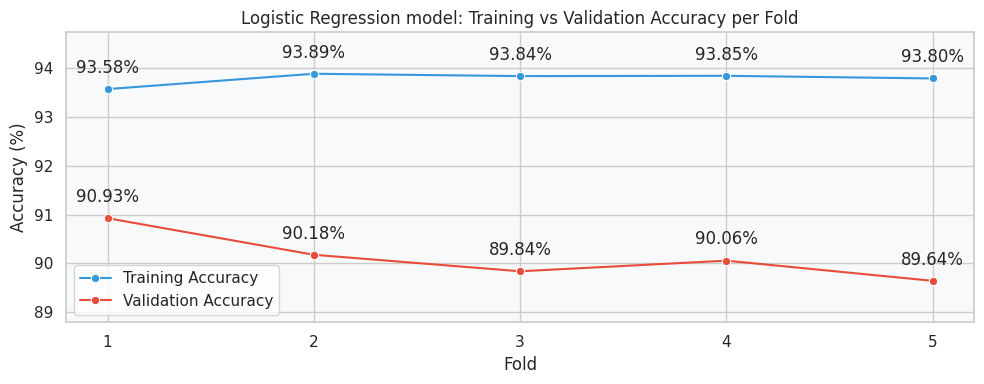

In [39]:
display_each_fold_result("Logistic Regression",lr_each_fold_results)

#### Model 1: Support Vector Machines (SVM)

In [40]:
svm_model= create_ml_model('svm', max_iter=5000)

In [41]:
svm_model, svm_each_fold_results, svm_results = kfold_evaluation(svm_model, X_oversampled_bow, y_oversampled_bow, skf)

In [42]:
display_all_folds_results("SVM", svm_results)

Average SVM Performance Metrics Across All Folds (on validation data):
- Accuracy: 90.87%
- Precision: 0.9107
- Recall: 0.9087
- F1 Score: 0.9082


SVM Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 96.11, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 89.72, Precision: 0.90, Recall: 0.90, F1: 0.90              
2     | Accuracy: 96.17, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 91.15, Precision: 0.91, Recall: 0.91, F1: 0.91              
3     | Accuracy: 95.99, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 91.44, Precision: 0.92, Recall: 0.91, F1: 0.91              
4     | Accuracy: 96.09, Precision: 0.96, Recall: 0.96, F1: 0.96               | Accuracy: 90.74, Precision: 0.91, Recall: 0.91, F1: 0.91              
5     | Accu

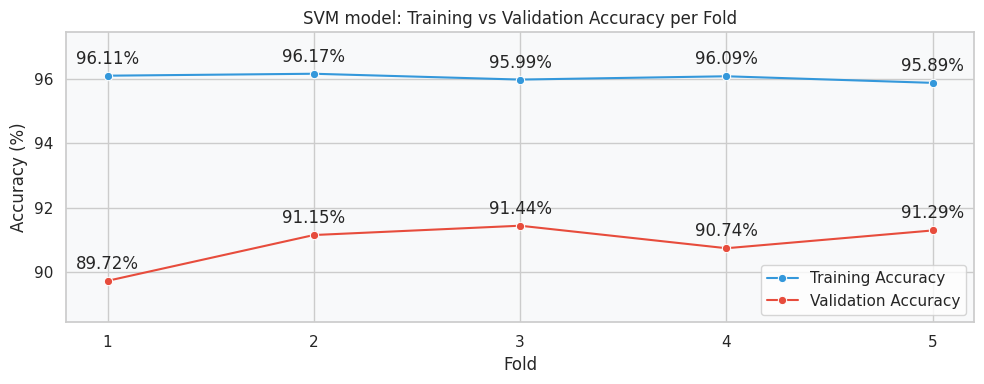

In [43]:
display_each_fold_result("SVM",svm_each_fold_results)

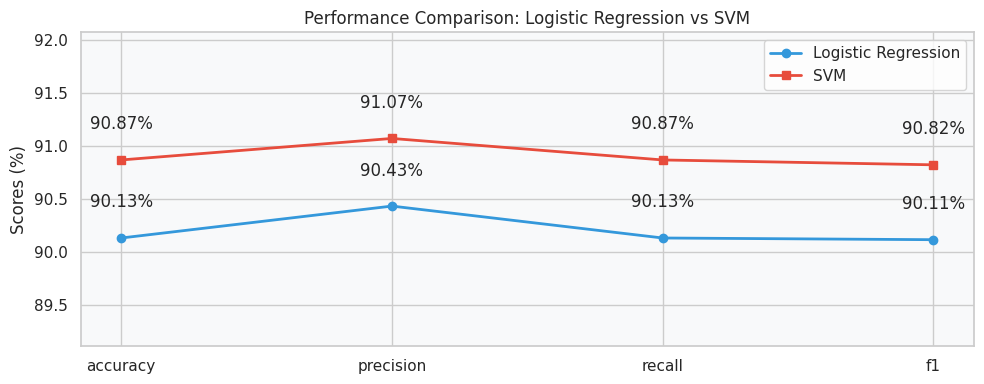

In [44]:
# Compare Model 1: Support Vector Machines model with Model 0: Logistic Regression
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=svm_results,
                                baseline_name='Logistic Regression', new_model_name='SVM')

#### Model 2: Random Forest

In [45]:
rf_model= create_ml_model('random_forest', n_estimators=100)

In [46]:
rf_model, rf_each_fold_results, rf_results = kfold_evaluation(rf_model, X_oversampled_bow, y_oversampled_bow, skf)

In [47]:
display_all_folds_results("Random Forest", rf_results)

Average Random Forest Performance Metrics Across All Folds (on validation data):
- Accuracy: 93.67%
- Precision: 0.9369
- Recall: 0.9367
- F1 Score: 0.9362


Random Forest Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 99.98, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.30, Precision: 0.93, Recall: 0.93, F1: 0.93              
2     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.61, Precision: 0.94, Recall: 0.94, F1: 0.94              
3     | Accuracy: 99.99, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 94.19, Precision: 0.94, Recall: 0.94, F1: 0.94              
4     | Accuracy: 99.98, Precision: 1.00, Recall: 1.00, F1: 1.00               | Accuracy: 93.23, Precision: 0.93, Recall: 0.93, F1: 0.93              
5 

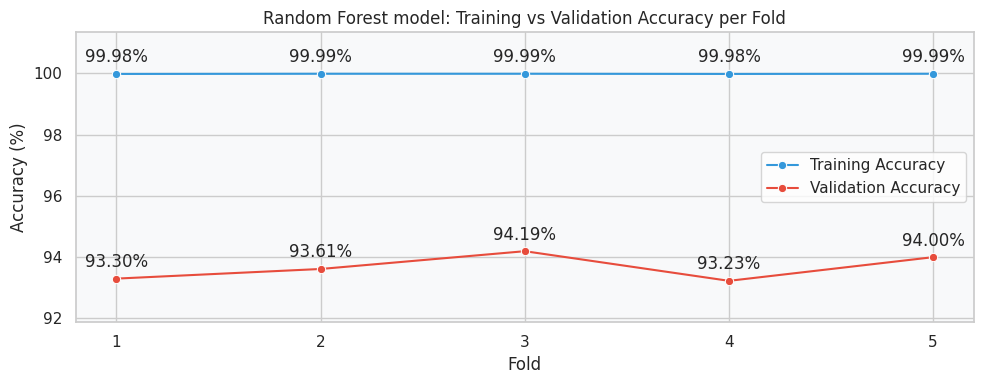

In [48]:
display_each_fold_result("Random Forest",rf_each_fold_results)

In [49]:
X_test_bow = vectorizer.transform(test_sentences)
y_test = test_labels

In [50]:
y_pred = rf_model.predict(X_test_bow)
y_true = y_test

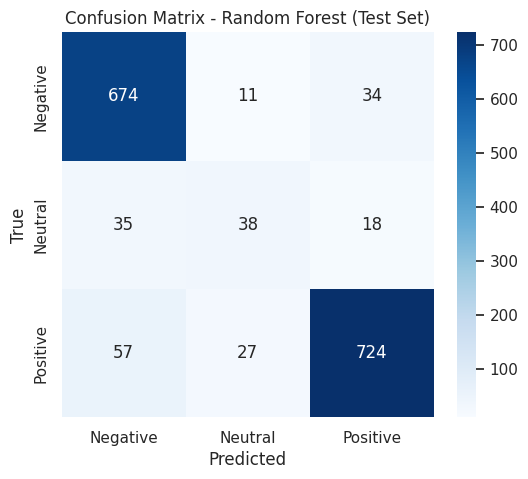

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Neutral','Positive'],
            yticklabels=['Negative','Neutral','Positive'])

plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Random Forest (Test Set)')

plt.savefig('confusion_matrix_rf.pdf')
plt.show()

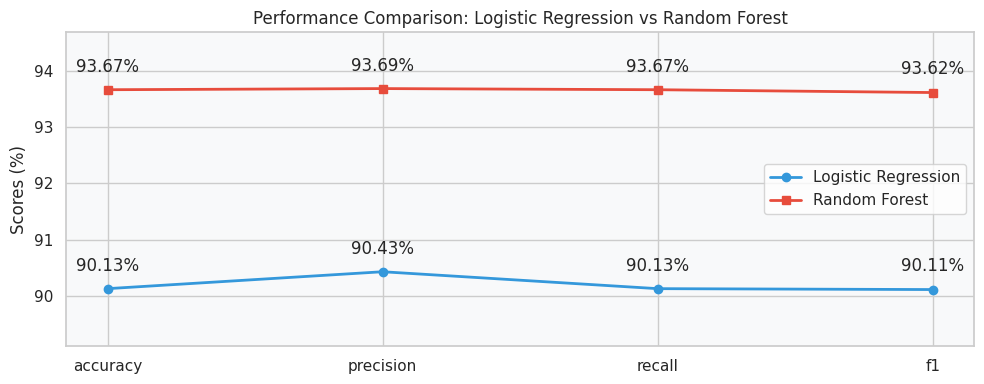

In [52]:
# Compare Model 2: Random Forest model with Model 0: Logistic Regression
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=rf_results,
                                baseline_name='Logistic Regression', new_model_name='Random Forest')

#### Model 3: Stacking SVM, Random Forest, Logistic Regression model

In [53]:
def create_ml_stacking_classifier(**kwargs):
    svm_model = make_pipeline(MaxAbsScaler(), LinearSVC(max_iter=10000))
    rf_model = RandomForestClassifier(n_estimators=100)
    lr_model = LogisticRegression(max_iter=10000, solver='saga', multi_class='multinomial')

    estimators = kwargs.get('estimators', [
        ('svm', svm_model),
        # ('rf', rf_model),
        ('lr', lr_model)
    ])
    final_estimator = kwargs.get('final_estimators', LogisticRegression(max_iter=10000, solver='saga'))

    return StackingClassifier(estimators, final_estimator)

In [54]:
ml_ensemble_model = create_ml_model('ml_ensemble')

In [55]:
ml_ensemble_model, ml_ensemble_each_fold_results, ml_ensemble_results = kfold_evaluation(ml_ensemble_model, X_oversampled_bow, y_oversampled_bow, skf)

In [56]:
display_all_folds_results("Machine Learning Ensemble", ml_ensemble_results)

Average Machine Learning Ensemble Performance Metrics Across All Folds (on validation data):
- Accuracy: 90.86%
- Precision: 0.9095
- Recall: 0.9086
- F1 Score: 0.9084


Machine Learning Ensemble Performance Metrics Across Each Fold (on training and validation data):

Fold  | Training Metrics                                                       | Validation Metrics                                                    
------------------------------------------------------------------------------------------------------------------------------------------------------
1     | Accuracy: 95.03, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 91.36, Precision: 0.92, Recall: 0.91, F1: 0.91              
2     | Accuracy: 95.10, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 91.29, Precision: 0.91, Recall: 0.91, F1: 0.91              
3     | Accuracy: 94.97, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.30, Precision: 0.90, Recall: 0.90, F1: 0.90              
4     | Accuracy: 95.24, Precision: 0.95, Recall: 0.95, F1: 0.95               | Accuracy: 90.54, Precision: 0.91, Recall: 0.91, F1: 0.91     

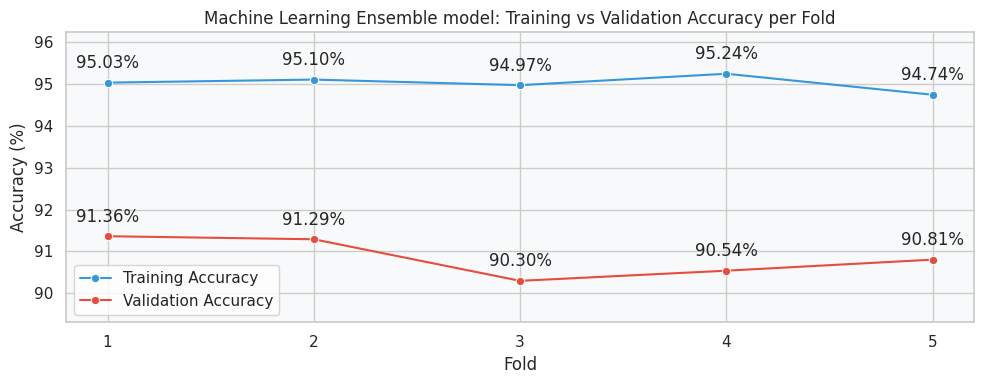

In [57]:
display_each_fold_result("Machine Learning Ensemble", ml_ensemble_each_fold_results)

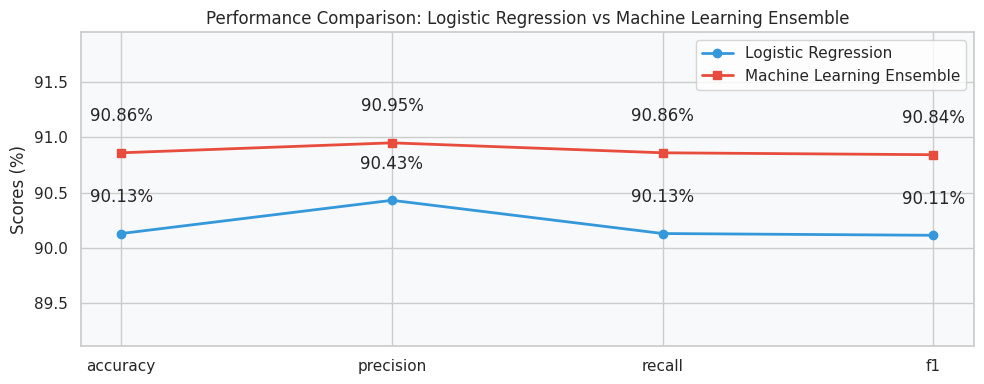

In [58]:
# Compare Model 3: Machine Learning Emsemble model with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=ml_ensemble_results,
                                baseline_name='Logistic Regression', new_model_name='Machine Learning Ensemble')

### Deep Learning Models

#### Optimized Parameters for DL training

In [59]:
# Default parameters
CV = ShuffleSplit(n_splits=2, test_size=0.1, random_state=42)
EPOCHS = 5
BATCH_SIZE = 32

In [60]:
# Parameters for RandomizedSearchCV
param_dist = {
    'learning_rate': [0.01, 0.001, 0.0001],
    'dense_units': [32, 64, 128],
    'dropout': [0.2, 0.3, 0.4, 0.5],
    'l1_reg': [0.001, 0.01, 0.1],
    'l2_reg': [0.001, 0.01, 0.1],
    'batch_normalization': [True, False],

    # options for convolutional layers
    'kernel_initializer': ["he_uniform", 'he_normal'],
    'padding': ['valid', 'same'],
}

In [61]:
# Split the data into training and validation sets (for deep learning model)
X_train, X_val, y_train, y_val = train_test_split(
    train_sentences_oversampled,
    train_labels_oversampled,
    test_size=0.1,  # 10% of the data will be used for validation
    random_state=42
)

#### Optimized Functions for DL training

In [62]:
def filter_param_dist_for_model(model_creation_fn, param_dist=param_dist):
    """
    Filter the parameter distribution dictionary to only include keys that are
    valid parameters for the given model creation function.

    Parameters:
    - param_dist: Original full parameter distribution dictionary.
    - model_creation_fn: Function used to create the model.

    Returns:
    - Filtered parameter distribution dictionary.
    """
    # Inspect the signature of the model creation function
    valid_params = signature(model_creation_fn).parameters.keys()

    # Filter the param_dist dictionary
    filtered_param_dist = {key: value for key, value in param_dist.items() if key in valid_params}

    return filtered_param_dist

In [63]:
import numpy as np
import tensorflow as tf
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV


class TextKerasClassifier(KerasClassifier):
    def _validate_data(self, X, y=None, reset=False, **check_params):
   
        if y is not None:
            dummy_X = np.zeros((len(X), 1))
            _, y_validated = super()._validate_data(dummy_X, y, reset=reset, **check_params)
            return X, y_validated
        return X

    def _fit_keras_model(self, X, y, sample_weight, warm_start, epochs, initial_epoch, **kwargs):
    
        X_tf = tf.convert_to_tensor(X, dtype=tf.string)
        return super()._fit_keras_model(X_tf, y, sample_weight, warm_start, epochs, initial_epoch, **kwargs)

    def predict(self, X, **kwargs):
        
        X_tf = tf.convert_to_tensor(X, dtype=tf.string)
        return super().predict(X_tf, **kwargs)

    def predict_proba(self, X, **kwargs):
        X_tf = tf.convert_to_tensor(X, dtype=tf.string)
        return super().predict_proba(X_tf, **kwargs)

def perform_random_search(model_creation_fn, model_name, param_dist=param_dist, X_train=X_train, y_train=y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, n_iter=3, cv=skf):
    """
    Perform Randomized Search for hyperparameter tuning on a deep learning model.
    """
    
  
    filtered_params = filter_param_dist_for_model(model_creation_fn)
    

    scikeras_param_dist = {
        'epochs': [3, 5],
        'batch_size': [16, 32, 64]
    }
    for key, value in filtered_params.items():
        scikeras_param_dist[f"model__{key}"] = value 
    
 
    keras_model = TextKerasClassifier(model=model_creation_fn, epochs=epochs, batch_size=batch_size, verbose=0)

    
    randomized_search = RandomizedSearchCV(estimator=keras_model, param_distributions=scikeras_param_dist, n_iter=n_iter, cv=cv, verbose=0)


    X_train_2d = np.array(X_train).reshape(-1, 1)

   
    randomized_search.fit(X_train_2d, y_train)

    print(f"\n{model_name} Model Results After Hyperparameter Tuning:\n")
    
    cv_results = randomized_search.cv_results_
    for params, mean_test_score, rank in zip(cv_results["params"], cv_results["mean_test_score"], cv_results["rank_test_score"]):
        print(f"Params: {params} - Mean Test Score: {mean_test_score:.2f} - Rank: {rank}")

    best_parameters = randomized_search.best_params_
    print(f"\nBest Parameters from {model_name} model: {best_parameters}\n")


    best_model = randomized_search.best_estimator_.model_

    return best_model

RandomizedSearchCV efficiently explores the hyperparameter space by randomly sampling a subset of parameter combinations and assessing their performance. When used together, they provide a robust and efficient method for hyperparameter tuning, ensuring that the model's performance is well-validated across multiple folds of the dataset.

In [64]:
def display_dl_results(best_model, model_name, X_val=X_val, y_val=y_val):
    """
    Display results of a deep learning model after hyperparameter tuning and evaluate on validation data.
    """
    # Display the best model's summary
    best_model.summary()

    # Predict on the validation set using the best model
    pred_probs = best_model.predict(X_val, verbose=0)
    class_preds = np.argmax(pred_probs, axis=1)

    # Calculate and display results (accuracy, precision, recall, and f1 score)
    results = calculate_results(y_true=y_val, y_pred=class_preds)
    print(f"\n{model_name} Validation Data Results:")
    for metric, score in results.items():
        print(f"- {metric.capitalize()}: {score:.2f}")

    return results

#### Model 1: Fully Connected Layers Model

Input (text) -> Tokenize -> Embedding -> Layers -> Output (label probability)

In [65]:
def create_fc_model(learning_rate=0.001, dense_units=32, dropout=0.5, l2_reg=0.01, activation='relu'):
    inputs = layers.Input(shape=(1, ), dtype="string")
    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='base_dense_embedding')(x)

    # Flatten the embeddings
    x = layers.Flatten()(x)

    # Add fully connected (Dense) layers with dropout
    x = layers.Dense(dense_units*2, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(3, activation="softmax")(x)

    model = Model(inputs, outputs, name="fully_connected_layers_model")
    model.compile(loss="sparse_categorical_crossentropy",
                  optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                  metrics=["accuracy"])
    return model

In [66]:
fc_model = perform_random_search(create_fc_model, model_name='Fully Connected Layers')


Fully Connected Layers Model Results After Hyperparameter Tuning:

Params: {'model__learning_rate': 0.01, 'model__l2_reg': 0.1, 'model__dropout': 0.3, 'model__dense_units': 128, 'epochs': 5, 'batch_size': 64} - Mean Test Score: nan - Rank: 1
Params: {'model__learning_rate': 0.001, 'model__l2_reg': 0.1, 'model__dropout': 0.3, 'model__dense_units': 32, 'epochs': 5, 'batch_size': 16} - Mean Test Score: nan - Rank: 1
Params: {'model__learning_rate': 0.001, 'model__l2_reg': 0.1, 'model__dropout': 0.3, 'model__dense_units': 32, 'epochs': 5, 'batch_size': 32} - Mean Test Score: nan - Rank: 1

Best Parameters from Fully Connected Layers model: {'model__learning_rate': 0.01, 'model__l2_reg': 0.1, 'model__dropout': 0.3, 'model__dense_units': 128, 'epochs': 5, 'batch_size': 64}



In [67]:
fc_model_results = display_dl_results(fc_model, model_name='Fully Connected Layers')

Model: "fully_connected_layers_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 24)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ base_dense_embedding            │ (None, 24, 128)        │     2,560,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_15 (Flatten)            │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_30 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_31 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,139,915 (38.68 MB)

 Trainable params: 3,379,971 (12.89 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,759,944 (25.79 MB)


Fully Connected Layers Validation Data Results:
- Accuracy: 86.07
- Precision: 0.86
- Recall: 0.86
- F1: 0.86


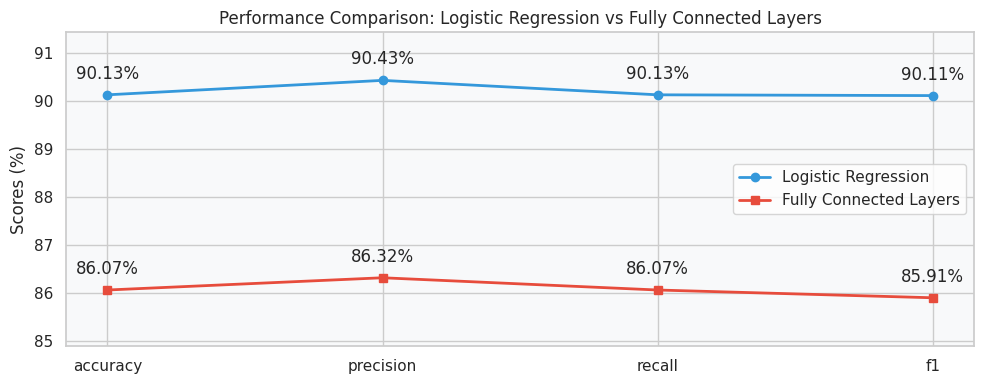

In [68]:
# Compare Model 1: Fully Connected Layer model with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=fc_model_results,
                                baseline_name='Logistic Regression', new_model_name='Fully Connected Layers')

### Dimensionality Reduction and Clustering

In [69]:
import tensorflow as tf
import numpy as np
import pandas as pd
from tensorflow.keras.models import Model

def extract_embeddings(model, sentences):
    """
    Extract embeddings for the input sentences, addressing the Keras 3 dtype mapping issue.
    """
    
    embedding_layer_model = Model(inputs=model.input, 
                                  outputs=model.get_layer('base_dense_embedding').output)
    
    
    if isinstance(sentences, pd.Series):
        sentences = sentences.tolist()
        
 
    sentences_2d = np.array(sentences).reshape(-1, 1)
    
  
    sentences_tf = tf.convert_to_tensor(sentences_2d, dtype=tf.string)

 
    intermediate_output = embedding_layer_model.predict(sentences_tf)

    return intermediate_output

# Extract embeddings using the trained fully connected model (fc_model)
test_embeddings = extract_embeddings(fc_model, test_sentences)

print(f"Embeddings matrix shape: {test_embeddings.shape}")

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Embeddings matrix shape: (1618, 24, 128)


In [70]:
len(test_embeddings[test_labels == 2]), len(test_embeddings[test_labels == 1]), len(test_embeddings[test_labels == 0])

(808, 91, 719)

In [71]:
positive_embeddings = test_embeddings[test_labels == 2][:50]
neutral_embeddings = test_embeddings[test_labels == 1][:50]
negative_embeddings = test_embeddings[test_labels == 0][:50]

positive_labels = np.array([2]*50)
neutral_labels = np.array([1]*50)
negative_labels = np.array([0]*50)

sampled_embeddings = np.concatenate([positive_embeddings, neutral_embeddings, negative_embeddings])
sampled_labels = np.concatenate([positive_labels, neutral_labels, negative_labels])

In [72]:
'''
The PCA algorithm expects a 2D array, but sampled_embeddings is a 3D array.
The shape of sampled_embeddings is (num_samples, sequence_length, embedding_dimension).

To resolve this, average (or max-pool, etc.) over the sequence length to get a 2D shape: (num_samples, embedding_dimension).

(sequence_length = MAX_LENGTH; embedding_dim = output_dim)
'''
sampled_embeddings.shape

if len(sampled_embeddings.shape) == 3:
    sampled_embeddings = np.mean(sampled_embeddings, axis=1)

In [73]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(sampled_embeddings)

kmeans = KMeans(n_clusters=3, n_init=10)
clustered_labels = kmeans.fit_predict(pca_result)

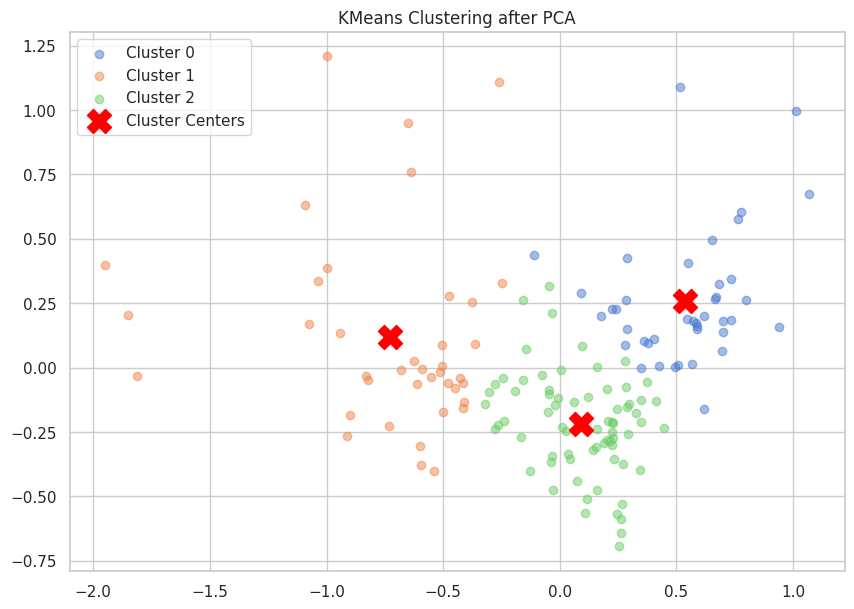

In [74]:
plt.figure(figsize=(10, 7))

for i in range(3): # [0, 1, 2] for [negative, neutral, positive]
    plt.scatter(pca_result[clustered_labels == i][:, 0],
                pca_result[clustered_labels == i][:, 1],
                label=f"Cluster {i}", alpha=0.5)

# Plotting cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            s=300, c='red', marker='X', label="Cluster Centers")

plt.legend()
plt.title('KMeans Clustering after PCA')
plt.show()

Batch Normalization in the GRU model serves to:
Normalize Activations: It ensures the outputs from the dense layer have a mean close to 0 and a standard deviation close to 1.

Stabilize Training: It stabilizes the gradient flow through the network, allowing for a smoother and faster training process.

Allow Higher Learning Rates: Due to the increased stability, the model can use higher learning rates, which can lead to quicker convergence.

Regularization: It adds slight noise to the activations, similar to Dropout, helping to prevent overfitting.

#### Model 2: GRU

Input (text) -> Tokenize -> Embedding -> Layers (GRU) -> Output (label probability)

In [75]:
def create_gru_model(learning_rate=0.01, dense_units=64, dropout=0.5, l2_reg=0.01, activation='relu', kernel_size=2, padding='valid', kernel_initializer="he_uniform", batch_normalization=True):
    inputs = layers.Input(shape=(1,), dtype="string")

    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='gru_embedding')(x)

    x = layers.GRU(dense_units, return_sequences=True, dropout=dropout)(x)
    x = layers.Conv1D(64, kernel_size=kernel_size, padding=padding, kernel_initializer=kernel_initializer)(x)
    x = layers.GlobalAveragePooling1D()(x)  # helps in reducing overfitting

    # Regularized dense layer
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    if batch_normalization:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)  # Dropout

    outputs = layers.Dense(3, activation="softmax")(x)
    model = Model(inputs, outputs, name="gru_model")

    model.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                metrics=["accuracy"])

    return model

In [76]:
gru_model = perform_random_search(create_gru_model, model_name='GRU')

I0000 00:00:1775569515.423683     162 cuda_dnn.cc:529] Loaded cuDNN version 91002



GRU Model Results After Hyperparameter Tuning:

Params: {'model__padding': 'valid', 'model__learning_rate': 0.01, 'model__l2_reg': 0.001, 'model__kernel_initializer': 'he_uniform', 'model__dropout': 0.3, 'model__dense_units': 64, 'model__batch_normalization': False, 'epochs': 5, 'batch_size': 16} - Mean Test Score: nan - Rank: 1
Params: {'model__padding': 'same', 'model__learning_rate': 0.01, 'model__l2_reg': 0.01, 'model__kernel_initializer': 'he_uniform', 'model__dropout': 0.5, 'model__dense_units': 32, 'model__batch_normalization': True, 'epochs': 5, 'batch_size': 64} - Mean Test Score: nan - Rank: 1
Params: {'model__padding': 'same', 'model__learning_rate': 0.01, 'model__l2_reg': 0.001, 'model__kernel_initializer': 'he_uniform', 'model__dropout': 0.3, 'model__dense_units': 32, 'model__batch_normalization': True, 'epochs': 5, 'batch_size': 64} - Mean Test Score: nan - Rank: 1

Best Parameters from GRU model: {'model__padding': 'valid', 'model__learning_rate': 0.01, 'model__l2_reg':

In [77]:
gru_model_results = display_dl_results(gru_model, model_name='GRU')

Model: "gru_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_31 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 24)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_embedding (Embedding)       │ (None, 24, 128)        │     2,560,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_15 (GRU)                    │ (None, 24, 64)         │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_15 (Conv1D)              │ (None, 23, 64)         │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_15     │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,829,579 (29.87 MB)

 Trainable params: 2,609,859 (9.96 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,219,720 (19.91 MB)


GRU Validation Data Results:
- Accuracy: 90.18
- Precision: 0.91
- Recall: 0.90
- F1: 0.90


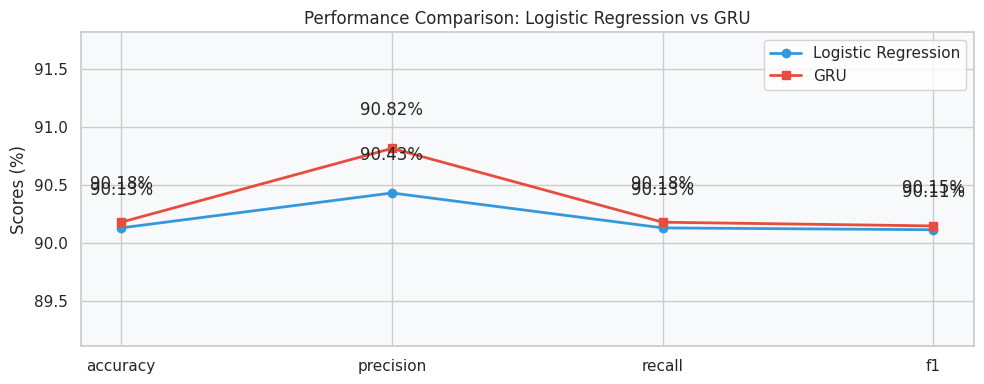

In [78]:
# Compare Model 2: GRU with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=gru_model_results,
                                baseline_name='Logistic Regression', new_model_name='GRU')

#### Model 3: Bidirectional LSTM

Input (text) -> Tokenize -> Embedding -> Bidirectional(Layers) -> Output (label probability)

In [79]:
def create_bidirectional_lstm_model(learning_rate=0.01, dense_units=64, dropout=0.5, l2_reg=0.01, activation='relu', batch_normalization=True):
    inputs = layers.Input(shape=(1,), dtype="string")

    x = text_vectorizer(inputs)
    x = create_embedding_layer(name='bidirectional_lstm_embedding')(x)

    # Bidirectional LSTM with dropout
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=True, dropout=dropout))(x)
    x = layers.Bidirectional(layers.LSTM(dense_units, dropout=dropout))(x)

    # Regularized dense layer
    x = layers.Dense(dense_units, activation=activation, kernel_regularizer=tf.keras.regularizers.l2(l2_reg))(x)
    if batch_normalization:
        x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)

    outputs = layers.Dense(3, activation="softmax")(x)
    model = Model(inputs, outputs, name="bidirectional_lstm_model")

    model.compile(loss="sparse_categorical_crossentropy",
                optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
                metrics=["accuracy"])

    return model

In [80]:
bidirectional_lstm_model = perform_random_search(create_bidirectional_lstm_model, model_name='Bidirectional LSTM')


Bidirectional LSTM Model Results After Hyperparameter Tuning:

Params: {'model__learning_rate': 0.001, 'model__l2_reg': 0.01, 'model__dropout': 0.3, 'model__dense_units': 32, 'model__batch_normalization': True, 'epochs': 3, 'batch_size': 32} - Mean Test Score: nan - Rank: 1
Params: {'model__learning_rate': 0.001, 'model__l2_reg': 0.001, 'model__dropout': 0.4, 'model__dense_units': 128, 'model__batch_normalization': True, 'epochs': 3, 'batch_size': 64} - Mean Test Score: nan - Rank: 1
Params: {'model__learning_rate': 0.01, 'model__l2_reg': 0.001, 'model__dropout': 0.5, 'model__dense_units': 32, 'model__batch_normalization': True, 'epochs': 3, 'batch_size': 64} - Mean Test Score: nan - Rank: 1

Best Parameters from Bidirectional LSTM model: {'model__learning_rate': 0.001, 'model__l2_reg': 0.01, 'model__dropout': 0.3, 'model__dense_units': 32, 'model__batch_normalization': True, 'epochs': 3, 'batch_size': 32}



In [81]:
bidirectional_lstm_model_results = display_dl_results(bidirectional_lstm_model, model_name='Bidirectional LSTM')

Model: "bidirectional_lstm_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_47 (InputLayer)     │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 24)             │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_lstm_embedding    │ (None, 24, 128)        │     2,560,000 │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_30                │ (None, 24, 256)        │       263,168 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_31                │ (None, 64)             │        73,984 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_110 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_25          │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_63 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,698,251 (33.18 MB)

 Trainable params: 2,899,395 (11.06 MB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 5,798,792 (22.12 MB)


Bidirectional LSTM Validation Data Results:
- Accuracy: 90.61
- Precision: 0.91
- Recall: 0.91
- F1: 0.91


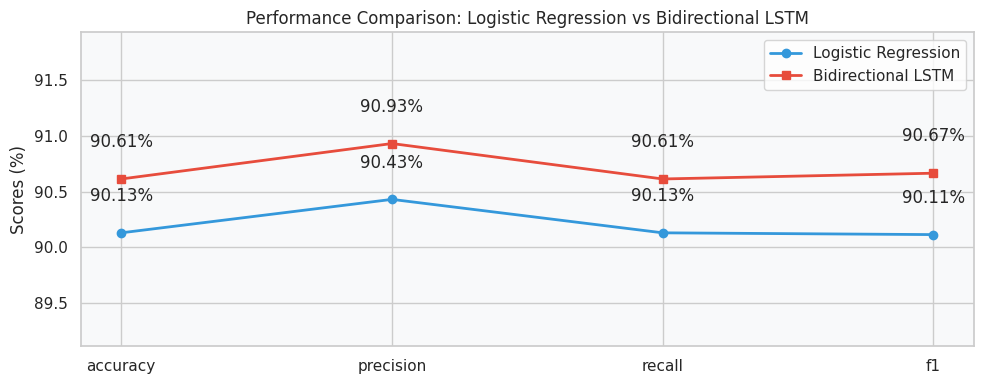

In [82]:
# Compare Model 3: Bidirectional RNN with Model 0: Logistic Regression model
compare_baseline_to_new_results(baseline_results=lr_results,
                                new_model_results=bidirectional_lstm_model_results,
                                baseline_name='Logistic Regression', new_model_name='Bidirectional LSTM')

In [83]:
# 1. Define a single file name with the .keras extension

model_path = "bidirectional_lstm_model.keras"

# 2. Save the model without the 'save_format' argument
bidirectional_lstm_model.save(model_path)

print(f"Model successfully saved as a single portable file: {model_path}")

Model successfully saved as a single portable file: bidirectional_lstm_model.keras


In [84]:
import os

# Define names
original_file = "bidirectional_lstm_model.keras"
final_name = "Final_Sentiment_Model.keras"

# Rename the file if it exists
if os.path.exists(original_file):
    os.rename(original_file, final_name)
    print(f"Successfully renamed to: {final_name}")
else:
    print("Check your saving cell! The .keras file was not found.")

Successfully renamed to: Final_Sentiment_Model.keras


In [85]:
!ls -R /kaggle/working

/kaggle/working:
confusion_matrix_rf.pdf      vietnamese_students_feedback_processed.csv
Final_Sentiment_Model.keras


In [86]:
import os
from tensorflow import keras

model_path = "/kaggle/working/Final_Sentiment_Model.keras"

if os.path.exists(model_path):
    
    loaded_model = keras.models.load_model(model_path)
    print(f"Successfully reloaded: {model_path}")
else:
    print("Error: Name mismatch. Please check the filename again.")

Successfully reloaded: /kaggle/working/Final_Sentiment_Model.keras


In [87]:
import tensorflow as tf

# Example sentence for sentiment analysis
test_comment = "Giảng viên nhiệt tình, bài giảng rất dễ hiểu!"

# 1. Chuyển thành mảng 2D (batch_size=1, features=1)
# 2. Ép kiểu thành tf.string
input_tensor = tf.convert_to_tensor([[test_comment]], dtype=tf.string)

# Dự đoán
predictions = loaded_model.predict(input_tensor)

# Hiển thị kết quả (Giả sử 0: Neg, 1: Neu, 2: Pos)
labels = ['Negative', 'Neutral', 'Positive']
print(f"Comment: {test_comment}")
print(f"Sentiment Result: {labels[np.argmax(predictions)]} ({np.max(predictions)*100:.2f}%)")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step
Comment: Giảng viên nhiệt tình, bài giảng rất dễ hiểu!
Sentiment Result: Positive (97.97%)


### PhoBert

In [88]:
import os
import shutil
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, Model
from transformers import AutoTokenizer, TFAutoModel
import logging
import warnings


warnings.filterwarnings('ignore')
logging.getLogger("transformers").setLevel(logging.ERROR)


print("Đang khởi tạo PhoBERT Tokenizer...")
phobert_tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

def encode_texts_for_phobert(sentences, max_length=128):
    if hasattr(sentences, 'tolist'):
        sentences = sentences.tolist()
        
    sentences = [str(text) for text in sentences]

    encodings = phobert_tokenizer(
        sentences,
        truncation=True,
        padding='max_length',
        max_length=max_length,
        return_tensors='tf' 
    )
    return encodings['input_ids'], encodings['attention_mask']

MAX_LEN = 128 
print("Đang mã hóa dữ liệu Train & Validation...")
train_input_ids, train_attention_mask = encode_texts_for_phobert(X_train, MAX_LEN)
val_input_ids, val_attention_mask = encode_texts_for_phobert(X_val, MAX_LEN)
print("✅ Mã hóa thành công!")







Đang khởi tạo PhoBERT Tokenizer...


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Đang mã hóa dữ liệu Train & Validation...
✅ Mã hóa thành công!


In [89]:
class PhoBertClassifier(Model):
    def __init__(self, num_classes=3, **kwargs):
        super(PhoBertClassifier, self).__init__(name="phobert_classifier", **kwargs)
        self.phobert = TFAutoModel.from_pretrained("vinai/phobert-base", from_pt=True)
        self.dropout = layers.Dropout(0.3)
        self.dense = layers.Dense(64, activation='relu')
        self.classifier = layers.Dense(num_classes, activation='softmax')

    def call(self, inputs, training=False):
        # Trích xuất input_ids và attention_mask từ dictionary
        input_ids = inputs['input_ids']
        attention_mask = inputs['attention_mask']

        # Đưa qua PhoBERT
        outputs = self.phobert({'input_ids': input_ids, 'attention_mask': attention_mask})
        cls_token = outputs[0][:, 0, :]
        
        # Phân loại
        x = self.dropout(cls_token, training=training)
        x = self.dense(x)
        return self.classifier(x)

print("Đang build model PhoBERT...")
phobert_model = PhoBertClassifier(num_classes=3) # Đổi số 3 nếu số lượng class của bạn khác

phobert_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=2e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Đang build model PhoBERT...


pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

In [90]:
print("Bắt đầu chuẩn bị dữ liệu và huấn luyện (Training)...")

y_train_np = np.array(y_train)
y_val_np = np.array(y_val)

history_phobert = phobert_model.fit(
    x={'input_ids': train_input_ids, 'attention_mask': train_attention_mask},
    y=y_train_np, 
    validation_data=({'input_ids': val_input_ids, 'attention_mask': val_attention_mask}, y_val_np), 
    epochs=3, 
    batch_size=16 
)


Bắt đầu chuẩn bị dữ liệu và huấn luyện (Training)...
Epoch 1/3


I0000 00:00:1775570193.087847     160 service.cc:152] XLA service 0x79c68c017c80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775570193.087889     160 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775570193.087895     160 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


   1/1163 ━━━━━━━━━━━━━━━━━━━━ 6:07:18 19s/step - accuracy: 0.3125 - loss: 1.2714

I0000 00:00:1775570199.527159     160 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1163/1163 ━━━━━━━━━━━━━━━━━━━━ 167s 127ms/step - accuracy: 0.4536 - loss: 1.0734 - val_accuracy: 0.6657 - val_loss: 0.8066
Epoch 2/3
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 134s 115ms/step - accuracy: 0.6651 - loss: 0.7879 - val_accuracy: 0.7286 - val_loss: 0.6754
Epoch 3/3
1163/1163 ━━━━━━━━━━━━━━━━━━━━ 133s 115ms/step - accuracy: 0.7192 - loss: 0.6735 - val_accuracy: 0.7654 - val_loss: 0.6045


In [91]:

production_dir = '/kaggle/working/phobert_production'
model_dir = os.path.join(production_dir, 'keras_model')
tokenizer_dir = os.path.join(production_dir, 'tokenizer')

os.makedirs(model_dir, exist_ok=True)
os.makedirs(tokenizer_dir, exist_ok=True)

# Keras 3 ưu tiên lưu định dạng .keras hoặc lưu weights đối với Class Model
phobert_model.save_weights(os.path.join(model_dir, 'phobert_weights.weights.h5'))
print(f"✅ Trọng số mô hình (Weights) đã được lưu tại: {model_dir}")

phobert_tokenizer.save_pretrained(tokenizer_dir)
print(f"✅ Tokenizer đã được lưu tại: {tokenizer_dir}")

zip_path = '/kaggle/working/phobert_production_bundle'
shutil.make_archive(zip_path, 'zip', production_dir)
print(f"🎉 DONE! Đã nén xong file production.")

✅ Trọng số mô hình (Weights) đã được lưu tại: /kaggle/working/phobert_production/keras_model
✅ Tokenizer đã được lưu tại: /kaggle/working/phobert_production/tokenizer
🎉 DONE! Đã nén xong file production.


Model: "phobert_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dropout_64 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 64)             │        49,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,235 (579.05 KB)

 Trainable params: 49,411 (193.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 98,824 (386.04 KB)


PhoBert Validation Data Results:
- Accuracy: 76.54
- Precision: 0.77
- Recall: 0.77
- F1: 0.76


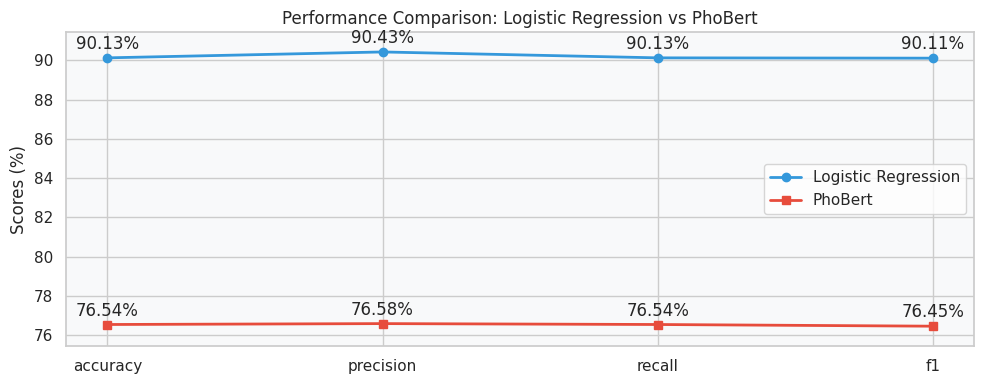

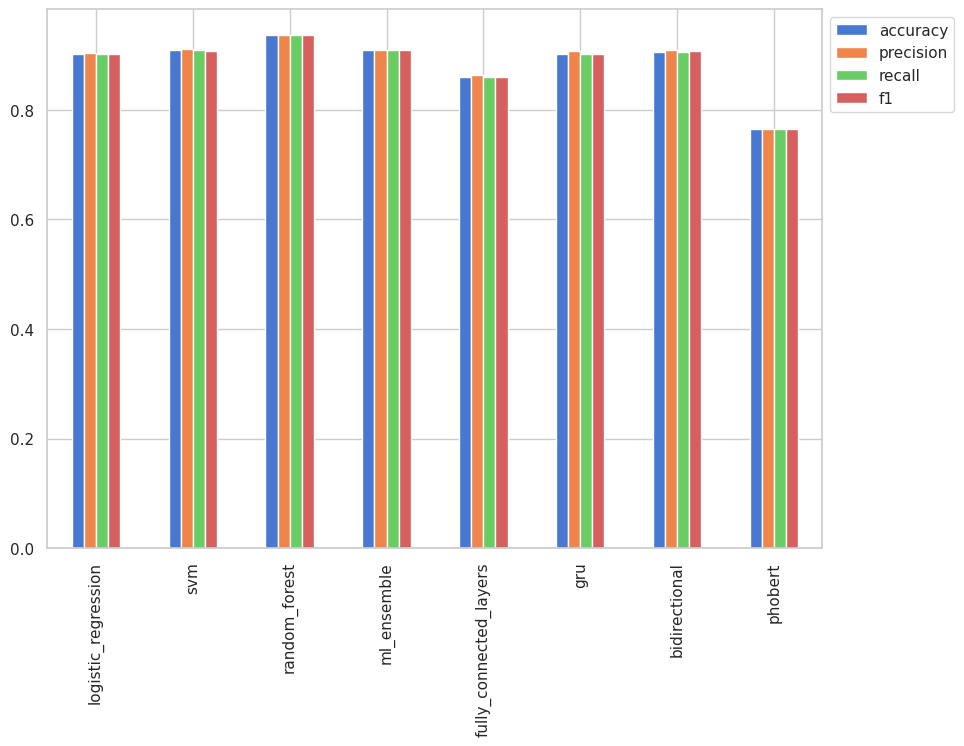

In [92]:

phobert_model_results = display_dl_results(
    best_model=phobert_model,            
    model_name='PhoBert',
    X_val={'input_ids': val_input_ids, 'attention_mask': val_attention_mask}, # Truyền dạng dict
    y_val=y_val                         
)

# Bảng so sánh với Logistic Regression
compare_baseline_to_new_results(
    baseline_results=lr_results,
    new_model_results=phobert_model_results,
    baseline_name='Logistic Regression', 
    new_model_name='PhoBert'
)


all_model_results = pd.DataFrame({
    'logistic_regression': lr_results,
    "svm": svm_results,
    'random_forest': rf_results,
    'ml_ensemble': ml_ensemble_results,
    "fully_connected_layers": fc_model_results,
    "gru": gru_model_results,
    "bidirectional": bidirectional_lstm_model_results,
    "phobert": phobert_model_results
})

all_model_results = all_model_results.transpose()
all_model_results["accuracy"] = all_model_results["accuracy"] / 100
all_model_results.plot(kind="bar", figsize=(10, 7)).legend(bbox_to_anchor=(1.0, 1.0));

### Compare Models

| Term | Description | Formula |
| --- | --- | --- |
| **Accuracy** | Accuracy is the ratio of the correctly predicted instances to the total instances in the dataset. It gives an overall performance measure of the model. | `(True Positives + True Negatives) / (Total Instances)` |
| **Precision** | Precision (also known as Positive Predictive Value) is the fraction of relevant instances among the retrieved instances. | `True Positives / (True Positives + False Positives)` |
| **Recall** | Recall (also known as Sensitivity or True Positive Rate) measures the number of true positive predictions among the actual positive instances in the dataset. | `True Positives / (True Positives + False Negatives)` |
| **F1-Score** | The F1-Score is the harmonic mean of precision and recall. | `2 * (Precision * Recall) / (Precision + Recall)` |

In [93]:
all_model_results = pd.DataFrame({'logistic_regression': lr_results,
                                  "svm": svm_results,
                                  'random_forest': rf_results,
                                  'ml_ensemble': ml_ensemble_results,
                                  "fully_connected_layers": fc_model_results,
                                  "gru": gru_model_results,
                                  "bidirectional": bidirectional_lstm_model_results,
                                  "phobert": phobert_model_results
                                 })
all_model_results = all_model_results.transpose()
all_model_results

,accuracy,precision,recall,f1
logistic_regression,90.130123,0.904309,0.901301,0.901141
svm,90.865568,0.910683,0.908656,0.908198
random_forest,93.666860,0.936871,0.936669,0.936167
ml_ensemble,90.860707,0.909508,0.908607,0.908433
fully_connected_layers,86.066763,0.863217,0.860668,0.859053
gru,90.179003,0.908151,0.901790,0.901469
bidirectional,90.614417,0.909331,0.906144,0.906663
phobert,76.536043,0.765815,0.765360,0.764499


### Model Evaluation

In [94]:
# Reverse mapping
reverse_label_map = {
    0: "negative",
    1: "neutral",
    2: "positive"
}

# Convert sentences to a list if they're in a Pandas Series
if isinstance(test_sentences, pd.Series):
    test_sentences = test_sentences.tolist()

In [95]:
ML_MODELS = {
    'SVM': svm_model,
    'Random Forest': rf_model,
    'Logistic Regression': lr_model,
    'Stacked ML Models': ml_ensemble_model
}

DL_MODELS = {
    "Fully Connected Layers": fc_model,
    "GRU": gru_model,
    "Bidirectional LSTM": bidirectional_lstm_model,
    "PhoBERT": phobert_model
}

# Define which models are deep learning models
is_deep_learning_dict = {
    'SVM': False,
    'Random Forest': False,
    'Logistic Regression': False,
    'Stacked ML Models': False,
    "Fully Connected Layers": True,
    "GRU": True,
    "Bidirectional LSTM": True,
    "PhoBERT": True
}

# Add a new dict to specifically identify PhoBERT
is_phobert_dict = {
    'SVM': False, 'Random Forest': False, 'Logistic Regression': False, 'Stacked ML Models': False,
    "Fully Connected Layers": False, "GRU": False, "Bidirectional LSTM": False,
    "PhoBERT": True
}
ALL_MODELS = {**ML_MODELS, **DL_MODELS}

print("Names of all available models:")
for model_type, models_dict in [('Machine Learning', ML_MODELS), ('Deep Learning', DL_MODELS)]:
    print(f"\n{model_type} Models:")
    for model_name in models_dict.keys():
        print(f"- {model_name}")

Names of all available models:

Machine Learning Models:
- SVM
- Random Forest
- Logistic Regression
- Stacked ML Models

Deep Learning Models:
- Fully Connected Layers
- GRU
- Bidirectional LSTM
- PhoBERT


In [96]:
import random
import numpy as np
import tensorflow as tf

def predict_on_multiple_sentences(model_name, sentences=test_sentences, actual_labels=test_labels.tolist(),
                                  is_deep_learning_dict=is_deep_learning_dict, vectorizer=vectorizer,
                                 
                                  tokenizer=phobert_tokenizer, max_length=128, 
                                  label_map=reverse_label_map, ALL_MODELS=ALL_MODELS, n=10):

    # Select n random sentences and corresponding labels
    n = min(n, len(sentences)) # ensure that n does not exceed the number of available sentences
    random_indices = random.sample(range(len(sentences)), n)
    random_sentences = [sentences[i] for i in random_indices]
    random_actual_labels = [actual_labels[i] for i in random_indices]

    model = ALL_MODELS[model_name]
    is_deep_learning = is_deep_learning_dict[model_name]

    # Print random n sentences
    for i, sentence in enumerate(random_sentences):
        if is_deep_learning:
            # Handle separately if the model is PhoBERT
            if model_name == 'PhoBERT':
                encoded = tokenizer(
                    sentence,
                    padding='max_length',
                    truncation=True,
                    max_length=max_length,
                    return_tensors='tf'
                )
              
                pred_probs = model.predict(
                    {'input_ids': encoded['input_ids'], 'attention_mask': encoded['attention_mask']}, 
                    verbose=0
                )

            # Handle for other DL models (TextVectorization is already included)
            else:
                pred_probs = model.predict([sentence], verbose=0)

            pred_labels = tf.argmax(pred_probs, axis=1).numpy()
            pred_prob = np.max(pred_probs, axis=1)[0]  # get the highest probability as the predicted probability

        else:
            test_features = vectorizer.transform([sentence])
            pred_labels = model.predict(test_features)

        # 0, 1, 2 --> negative, neutral, positive
    
        mapped_pred_label = label_map[int(pred_labels[0]) if not is_deep_learning else pred_labels[0]]
        mapped_actual_label = label_map[random_actual_labels[i]]

        print(f"Text: {sentence}")
        if is_deep_learning:
            print(f"Prediction: {mapped_pred_label} | Probability: {pred_prob * 100:.2f}% | Actual: {mapped_actual_label}\n")
        else:
            print(f"Prediction: {mapped_pred_label} | Actual: {mapped_actual_label}\n")

# Call the test function
predict_on_multiple_sentences(model_name='PhoBERT', n=10)

Text: chấm điểm khó vì phải kết_quả đúng mới chấm điểm không chấm_điểm từng bước
Prediction: negative | Probability: 71.60% | Actual: negative

Text: có cung_cấp tài_liệu cho sinh_viên
Prediction: positive | Probability: 39.78% | Actual: neutral

Text: trình_độ chuyên_môn đáng ngại
Prediction: neutral | Probability: 46.26% | Actual: negative

Text: đến lớp muộn 15 phút ra sớm từ 15 đến 30 phút
Prediction: negative | Probability: 50.51% | Actual: negative

Text: có đề_cương cơ_bản chung
Prediction: neutral | Probability: 50.75% | Actual: neutral

Text: nhiều khi làm bài_tập mình không biết mình đang làm gì luôn
Prediction: negative | Probability: 76.69% | Actual: negative

Text: thầy luôn tích_cực trả_lời thắc_mắc của sinh_viên trên modle
Prediction: positive | Probability: 89.48% | Actual: positive

Text: cô dạy rất tận_tâm nhiệt_tình
Prediction: positive | Probability: 97.80% | Actual: positive

Text: khối_lượng lý_thuyết và thực_hành phải học quá ôm_đồm trong một môn_học
Prediction: 

In [97]:
import numpy as np
import tensorflow as tf

def check_most_wrong(model, model_name, sentences, actual_labels, reverse_label_map, n=10, tokenizer=None, max_length=128):
   
    print(f"Đang phân tích sai sót cho mô hình {model_name}...")
    
    if model_name == 'PhoBERT':
        
        encoded = tokenizer(
            list(sentences), padding='max_length', truncation=True,
            max_length=max_length, return_tensors='tf'
        )
        pred_probs = model.predict({'input_ids': encoded['input_ids'], 'attention_mask': encoded['attention_mask']}, verbose=0)
    else:
       
        sentences_tensor = tf.convert_to_tensor(list(sentences), dtype=tf.string)
        pred_probs = model.predict(sentences_tensor, verbose=0)


    pred_labels = np.argmax(pred_probs, axis=1)
    
    wrong_predictions = []

    for i in range(len(sentences)):
        actual_label_idx = actual_labels[i]
        
   
        if pred_labels[i] != actual_label_idx:
       
            prob_actual = pred_probs[i][actual_label_idx]
            prob_pred = np.max(pred_probs[i])

            prob_diff = abs(prob_actual - prob_pred)

            mapped_pred_label = reverse_label_map[pred_labels[i]]
            mapped_actual_label = reverse_label_map[actual_label_idx]

            wrong_predictions.append({
                "sentence": sentences[i],
                "predicted_label": mapped_pred_label,
                "actual_label": mapped_actual_label,
                "probability_diff": prob_diff
            })

 
    most_wrong_predictions = sorted(wrong_predictions, key=lambda x: x["probability_diff"], reverse=True)

    print(f"\n--- TOP {n} CÂU DỰ ĐOÁN SAI NHIỀU NHẤT ---")
    for prediction in most_wrong_predictions[:n]:
        print(f"Text: {prediction['sentence']}")
        print(f"Prediction: {prediction['predicted_label']}",
              f"| Probability Difference: {prediction['probability_diff'] * 100:.2f}%",
              f"| Actual: {prediction['actual_label']}\n")


actual_labels = test_labels.tolist()
actual_test_sentences = test_sentences

# Test với Bidirectional LSTM
check_most_wrong(
    model=bidirectional_lstm_model, 
    model_name='Bidirectional LSTM', 
    sentences=actual_test_sentences, 
    actual_labels=actual_labels, 
    reverse_label_map=reverse_label_map, 
    n=10
)

# Test với PhoBERT (Bạn có thể bỏ comment dòng dưới để chạy thử)
# check_most_wrong(
#     model=phobert_model, 
#     model_name='PhoBERT', 
#     sentences=actual_test_sentences, 
#     actual_labels=actual_labels, 
#     reverse_label_map=reverse_label_map, 
#     tokenizer=phobert_tokenizer,
#     n=10
# )

Đang phân tích sai sót cho mô hình Bidirectional LSTM...

--- TOP 10 CÂU DỰ ĐOÁN SAI NHIỀU NHẤT ---
Text: đó là điều mà em mong_muốn mỗi khi đến lớp
Prediction: neutral | Probability Difference: 99.80% | Actual: positive

Text: nhiệt_tình tận_tâm giải_đáp các thắc_mắc
Prediction: positive | Probability Difference: 99.78% | Actual: negative

Text: giảng_viên xuất_sắc
Prediction: neutral | Probability Difference: 99.58% | Actual: positive

Text: thầy đảm_bảo tốt về giờ lên lớp
Prediction: positive | Probability Difference: 99.32% | Actual: neutral

Text: bài thực_hành nên mang tính_chất bắt_buộc hoặc khuyến_khích sinh_viên làm để lấy điểm cộng để tạo động_lực cũng như hứng_thú với bài thực_hành hơn
Prediction: negative | Probability Difference: 99.31% | Actual: positive

Text: như_vậy là được
Prediction: neutral | Probability Difference: 99.21% | Actual: positive

Text: lên lớp đều_đặn
Prediction: neutral | Probability Difference: 99.14% | Actual: positive

Text: em xin cảm_ơn
Prediction

In [98]:
import tensorflow as tf


def evaluate_model_on_test_data(model, model_name, test_sentences, test_labels, vectorizer, tokenizer=None, max_length=128, is_deep_learning=False):
    '''
    Accept both ML and DL models
    Evaluate selected model on test data
    '''
    if is_deep_learning:
        if model_name == 'PhoBERT':
    
            encoded = tokenizer(
                list(test_sentences),
                padding='max_length',
                truncation=True,
                max_length=max_length,
                return_tensors='tf'
            )
        
            pred_probs = model.predict({'input_ids': encoded['input_ids'], 'attention_mask': encoded['attention_mask']})
        else:
       
            sentences_tensor = tf.convert_to_tensor(list(test_sentences), dtype=tf.string)
            pred_probs = model.predict(sentences_tensor)

        pred_labels = tf.argmax(pred_probs, axis=1).numpy()

    else:
        # Basic ML models
        test_features = vectorizer.transform(test_sentences) 
        pred_labels = model.predict(test_features)

    # Calculate evaluation metrics
    results = calculate_results(test_labels, pred_labels)

    return pred_labels, results

In [99]:
def get_models_performance(models_dict, test_sentences, test_labels, vectorizer, tokenizer=None, is_deep_learning_dict=None):
    """
    Iterate through the model list and calculate performance
    """
    performance = {}
    for model_name, model in models_dict.items():
        print(f"Evaluating {model_name}...")

     
        is_dl = is_deep_learning_dict[model_name] if is_deep_learning_dict else False

      
        _, results = evaluate_model_on_test_data(
            model=model,
            model_name=model_name,
            test_sentences=test_sentences,
            test_labels=test_labels,
            vectorizer=vectorizer,
            tokenizer=tokenizer,
            is_deep_learning=is_dl
        )

        performance[model_name] = results
    return performance

In [100]:
model_name = "PhoBERT"

pred_labels, test_results_dl = evaluate_model_on_test_data(
    model=ALL_MODELS[model_name],
    model_name=model_name,              
    test_sentences=test_sentences,
    test_labels=test_labels,
    vectorizer=vectorizer,

    tokenizer=phobert_tokenizer,                
    is_deep_learning=is_deep_learning_dict[model_name]
)

print(test_results_dl)

51/51 ━━━━━━━━━━━━━━━━━━━━ 13s 248ms/step
{'accuracy': 79.17181705809642, 'precision': np.float64(0.8368816323893253), 'recall': np.float64(0.7917181705809642), 'f1': np.float64(0.809499432141732)}


In [101]:
def select_best_model_from_dict(performance_dict, metric='accuracy'):
    best_model_name = None
    best_score = -1
    
    for model_name, results in performance_dict.items():
    
        score = results.get(metric, 0)
        if score > best_score:
            best_score = score
            best_model_name = model_name
            
    return best_model_name, best_score


# Run evaluations for model groups 
ml_models_performance = get_models_performance(
    ML_MODELS, test_sentences, test_labels,
    vectorizer=vectorizer,
    is_deep_learning_dict=is_deep_learning_dict
)

dl_models_performance = get_models_performance(
    DL_MODELS, test_sentences, test_labels,
    vectorizer=vectorizer,
    tokenizer=phobert_tokenizer, 
    is_deep_learning_dict=is_deep_learning_dict
)

# Find the best model
best_ml_model_name, best_ml_model_score = select_best_model_from_dict(ml_models_performance, metric='accuracy')
best_dl_model_name, best_dl_model_score = select_best_model_from_dict(dl_models_performance, metric='accuracy')

print(f"\n--- KẾT QUẢ TỔNG KẾT ---")
print(f"Best ML Model: {best_ml_model_name} ({best_ml_model_score:.2f}%)")
print(f"Best DL Model: {best_dl_model_name} ({best_dl_model_score:.2f}%)")

Evaluating SVM...
Evaluating Random Forest...
Evaluating Logistic Regression...
Evaluating Stacked ML Models...
Evaluating Fully Connected Layers...
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Evaluating GRU...
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Evaluating Bidirectional LSTM...
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Evaluating PhoBERT...
51/51 ━━━━━━━━━━━━━━━━━━━━ 10s 190ms/step

--- KẾT QUẢ TỔNG KẾT ---
Best ML Model: Random Forest (88.75%)
Best DL Model: Bidirectional LSTM (88.75%)
